In [1]:
import qiskit

# ⚛️ Shor's Algorithm (Step 1: The Concept)

## 1. What problem does it solve?

To understand Shor's Algorithm, you first need to understand **RSA Encryption**. This is the security system that protects almost everything on the internet (your bank passwords, WhatsApp messages, etc.).

RSA is based on a simple math trick:

* **Easy:** Multiplying two huge prime numbers together (e.g., $P \times Q = N$).
* **Practically Impossible:** Taking that massive number $N$ and figuring out which two prime numbers were multiplied to create it. This is called **Prime Factorization**.

A classical supercomputer would take millions of years to factor a 2048-bit RSA number. Shor's Algorithm on a powerful quantum computer could theoretically do it in hours or days.

## 2. The Hybrid Approach

The biggest secret about Shor's Algorithm is that **it is not 100% quantum**. It is a hybrid algorithm divided into two distinct parts:

* **Part A: The Classical Reduction (Math on a normal laptop)**
Instead of trying to factor the number directly, we use classical number theory to transform the factoring problem into a completely different puzzle called the **Period Finding Problem**.
* **Part B: The Quantum Heavy Lifting (The Quantum Computer)**
Classical computers are terrible at finding this "period." So, we hand this specific puzzle over to the quantum computer. The quantum computer uses a tool called the **Quantum Fourier Transform (QFT)** to find the period exponentially fast and hands the answer back to our laptop.
* **Part C: The Final Classical Step**
Our laptop takes that period, does some basic high-school math, and reveals the prime factors!




# ⚛️ Shor's Algorithm (Step 2: The Classical Math Trick)

## 1. Theory: The Period Finding Problem

Let's say we want to factor the number **$N = 15$**. (We know the answer is $3 \times 5$, but let's pretend we don't).

Here is the classical algorithm Shor uses:

1. **Pick a random guess ($a$):** Pick any number smaller than $15$. Let's pick **$a = 7$**.
2. **Check if you got lucky:** Check the Greatest Common Divisor (GCD) of $7$ and $15$. If it's not $1$, you found a factor! (Here, $gcd(7, 15) = 1$, so no luck yet).
3. **The Magic Function:** We create a sequence using this modular arithmetic formula:

$$f(x) = a^x \pmod{N}$$



Let's plug in $x = 0, 1, 2, 3, 4 \dots$ and see what happens:
* $7^0 \pmod{15} = 1$
* $7^1 \pmod{15} = 7$
* $7^2 \pmod{15} = 49 \pmod{15} = 4$
* $7^3 \pmod{15} = 343 \pmod{15} = 13$
* $7^4 \pmod{15} = 2401 \pmod{15} = \textbf{1}$ *(Look! It repeated!)*
* $7^5 \pmod{15} = \textbf{7}$



**The Period ($r$):**
The sequence is `1, 7, 4, 13`, and then it repeats. The length of this repeating pattern is **$r = 4$**.

**Getting the Factors:**
Once we have that period $r$, we use a simple math formula to get the prime factors:


$$\text{Factor 1} = \gcd(a^{r/2} + 1, N)$$

$$\text{Factor 2} = \gcd(a^{r/2} - 1, N)$$


Let's test it:

* $7^{4/2} = 7^2 = 49$
* $\gcd(49 + 1, 15) = \gcd(50, 15) = \textbf{5}$
* $\gcd(49 - 1, 15) = \gcd(48, 15) = \textbf{3}$

Boom! The factors are 5 and 3! The *only* hard part of this entire process is finding that period $r$ when $N$ is a massive 2048-bit number.

---

## 2. Code: Classical Period Finding

Let's write a simple Python script to prove this works. This is what your classical laptop does *before* calling the quantum computer.






In [2]:
import math

# 1. Our target number and our random guess
N = 15
a = 7

print(f"Trying to factor N={N} with random guess a={a}\n")

# 2. Let's find the period (r) classically
# Note: For massive numbers, this loop would take millions of years!
r = 0
for x in range(1, N):
    result = (a**x) % N
    print(f"{a}^{x} mod {N} = {result}")
    
    if result == 1: # The pattern always loops back to 1
        r = x
        break

print(f"\nPattern repeated! The period 'r' is: {r}")

# 3. Check if r is even (Shor's math requires an even period)
if r % 2 != 0:
    print("Period is odd. We must pick a different random guess 'a'.")
else:
    # 4. Calculate the factors using GCD
    factor1 = math.gcd(a**(r//2) + 1, N)
    factor2 = math.gcd(a**(r//2) - 1, N)
    
    print(f"Factor 1: {factor1}")
    print(f"Factor 2: {factor2}")
    print(f"Success! {factor1} * {factor2} = {N}")


Trying to factor N=15 with random guess a=7

7^1 mod 15 = 7
7^2 mod 15 = 4
7^3 mod 15 = 13
7^4 mod 15 = 1

Pattern repeated! The period 'r' is: 4
Factor 1: 5
Factor 2: 3
Success! 5 * 3 = 15




## 3. Exercises (Hands-on Practice)

### Exercise 1: Try a different guess

**Goal:** Prove that the math works even if we pick a different random number.

* **Task:** Change `a = 7` to `a = 2` in the code above.
* **Observation:** Run it. What is the new period $r$? Does it still give you the correct factors of 15?

### Exercise 2: The "Bad" Guess

**Goal:** See what happens when the math fails.

* **Task:** Change the guess to `a = 14`.
* **Observation:** The period $r$ will be 2. When you calculate the factors, you will get 15 and 1. This is a "trivial factor" (it didn't help us find 3 and 5). In Shor's algorithm, if this happens, the computer just picks a new random guess and tries again!



# Shor's Algorithm (Step 3: The Quantum Engine)

## 1. Theory: How the Quantum Computer Finds the Period

To find the period $r$ for our numbers $a = 7$ and $N = 15$, we build a circuit with two sets of qubits:

1. **Register 1 (Counting Qubits):** We use 4 qubits here. We put them into a massive superposition. These will act as our "control" switches.
2. **Register 2 (Target Qubits):** We use 4 qubits here, initialized to the number $1$ (state $\vert{}0001\rangle$). We will apply our math function to these qubits.

**The 3-Step Quantum Process:**

* **Step 1: Superposition.** We apply Hadamard ($H$) gates to all Counting Qubits to create a superposition of all possible guesses.
* **Step 2: Controlled Modular Exponentiation.** We apply a special "Black Box" gate that multiplies our Target Qubits by $7^x \pmod{15}$. Because the Counting Qubits are in superposition, we calculate the answer for *all* values of $x$ simultaneously. This entangles the period's pattern into the phase of the counting qubits.
* **Step 3: Inverse Quantum Fourier Transform (IQFT).** This is the ultimate codebreaker. The IQFT reads the complicated phase patterns created in Step 2 and converts them into a readable spike on our histogram. We measure it, and it gives us a fraction that contains our period $r$!

---

## 2. Code: The Quantum Phase Estimation Circuit

Writing the exact gate-level code for $7^x \pmod{15}$ is extremely long. In this code, we create the structure of Shor's quantum phase estimation using Qiskit's built-in `QFT` library and a custom function for the modular multiplication.





C:\Users\viraj\AppData\Local\Temp\ipykernel_18228\108856833.py:45: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(N_COUNT, inverse=True, do_swaps=True), range(N_COUNT))


Shor's Algorithm (Quantum Phase Estimation for a=7, N=15):


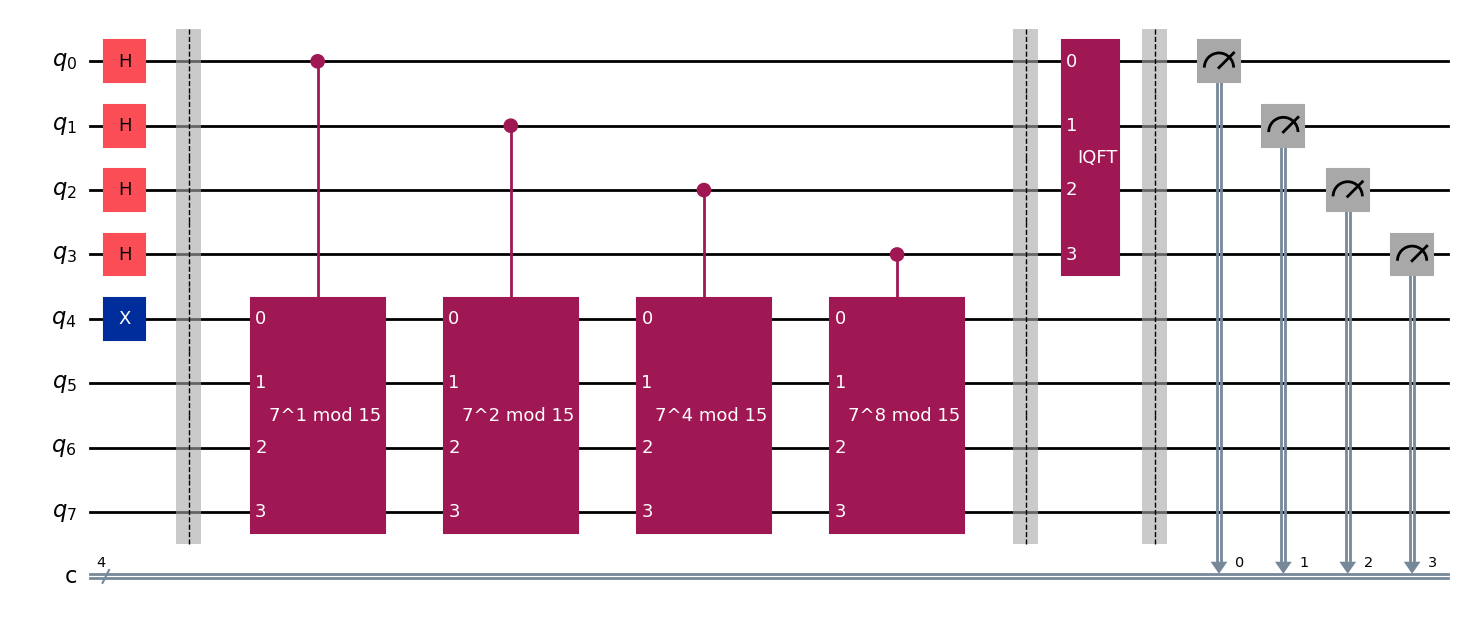

Transpiling circuit for the simulator... (This might take a few seconds)


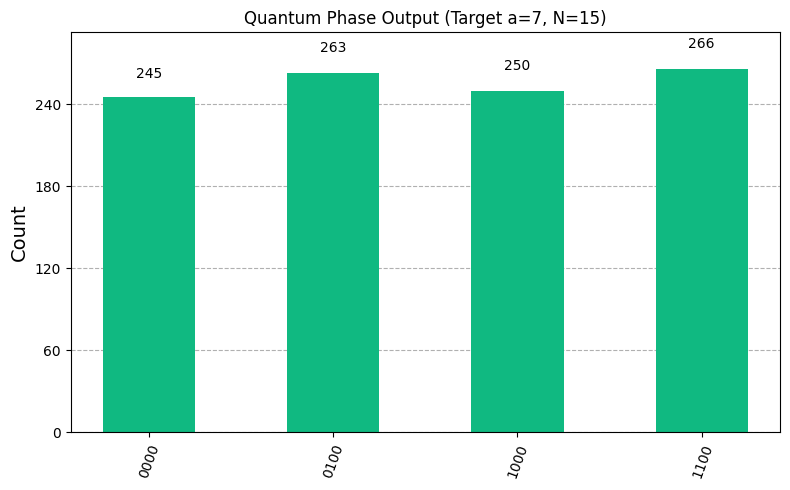

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile # Make sure to import transpile!

# --- 1. Helper Function: The "Black Box" (7^x mod 15) ---
# This creates a controlled unitary gate for our specific math problem.
def c_amod15(power):
    """Controlled multiplication by 7 mod 15"""
    U = QuantumCircuit(4)
    # The mathematical logic for multiplying by 7^power mod 15
    for _iteration in range(power):
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)
        for q in range(4):
            U.x(q)
    U_gate = U.to_gate(label=f"7^{power} mod 15")
    return U_gate.control()

# --- 2. Initialize the Circuit ---
N_COUNT = 4  # Number of counting qubits
qc = QuantumCircuit(N_COUNT + 4, N_COUNT) # 4 counting + 4 target, 4 classical bits

# Step 1: Initialize Counting Qubits in superposition (H-gates)
qc.h(range(N_COUNT))

# Initialize Target Qubits to state |1> (binary 0001)
qc.x(N_COUNT) 

qc.barrier()

# --- 3. Step 2: Apply Controlled Modular Exponentiation ---
# We apply the black box 1, 2, 4, and 8 times depending on the control qubit
for q in range(N_COUNT):
    # Apply the controlled-U gate
    qc.append(c_amod15(2**q), [q] + [i+N_COUNT for i in range(4)])
    
qc.barrier()

# --- 4. Step 3: Apply Inverse QFT ---
# We use Qiskit's built-in QFT function, inverted, on the counting qubits
qc.append(QFT(N_COUNT, inverse=True, do_swaps=True), range(N_COUNT))

qc.barrier()

# --- 5. Measure the Counting Qubits ---
qc.measure(range(N_COUNT), range(N_COUNT))

# --- Visualize Circuit ---
print("Shor's Algorithm (Quantum Phase Estimation for a=7, N=15):")
display(qc.draw('mpl', fold=60))
# --- 6. Simulate and Get Results ---
sim = AerSimulator()

# THE FIX: Transpile the circuit so the simulator can break down our custom math gates
print("Transpiling circuit for the simulator... (This might take a few seconds)")
transpiled_qc = transpile(qc, backend=sim)

# Run the TRANSPILED circuit instead of the raw one!
result = sim.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

# --- Visualization ---
fig = plot_histogram(
    counts, 
    title="Quantum Phase Output (Target a=7, N=15)", 
    figsize=(8, 5), 
    color='#10b981' 
)
display(fig)


## 3. Exercises (Hands-on Practice)

### Exercise 1: Analyze the Histogram

**Goal:** Understand what the quantum computer actually outputs.

* **Task:** Run the code above. Look at the histogram. You will see spikes at exactly four binary values: `0000` (0), `0100` (4), `1000` (8), and `1100` (12).
* **Explanation:** The quantum computer doesn't spit out $r = 4$ directly. It spits out *phases*. These phases map to fractions: $0/16$, $4/16$, $8/16$, and $12/16$. If you simplify those fractions, you get $0$, $1/4$, $1/2$, and $3/4$. The **denominator** of these simplified fractions gives you the period: $r = 4$!

### Exercise 2: The IQFT Impact

**Goal:** See why the Inverse Quantum Fourier Transform is strictly necessary.

* **Task:** In the code, comment out the line that applies the `QFT(N_COUNT, inverse=True, do_swaps=True)`. Run the circuit again.
* **Observation:** Your histogram will turn into random noise. Without the IQFT, the phase information remains hidden inside the quantum amplitudes. The IQFT is the lens that focuses that hidden phase into a readable binary number.


# Real-World Scenario: The Quantum Bank Heist (Breaking RSA)

## 1. The Setup: How the World Stays Safe

Right now, every time you send a WhatsApp message, buy something on Amazon, or log into your HDFC/SBI bank account, your data is locked using **RSA Encryption**.

RSA works on a "Public Key" system.

* **The Public Key (The Lock):** The bank gives everyone a massive number, **$N$**. Let's pretend the bank uses $N = 33$. (In reality, $N$ is a number with 600 digits!). Anyone can use this lock to secure a message.
* **The Private Key (The Key):** The only way to unlock the message is to know the two secret prime numbers that multiply to create $N$.

For classical computers, finding out that $3 \times 11 = 33$ is easy. But if $N$ has 600 digits, the world's fastest supercomputer would take **300 trillion years** to find the two secret prime numbers. Your bank account is safe!

## 2. The Heist: Enter the Quantum Hacker

Imagine a hacker intercepts a highly classified, encrypted bank transfer of ₹100 Crores. The hacker only sees the public lock: $N = 33$.

Instead of a normal laptop, the hacker boots up a **Quantum Computer** and runs Shor's Algorithm:

* **Step 1 (Classical Guess):** The hacker's laptop picks a random number, say $a = 5$.
* **Step 2 (Quantum Magic):** The hacker sends $N = 33$ and $a = 5$ to the Quantum Computer. Using the **Quantum Fourier Transform (QFT)**, the computer explores all possible repeating patterns simultaneously. In exactly one shot, the quantum machine spits out a phase fraction that tells the hacker the repeating period is **$r = 10$**.
* **Step 3 (The Break-In):** The hacker plugs $r = 10$ back into their classical laptop using simple math:
* $\text{Factor 1} = \gcd(5^{10/2} + 1, 33) = \mathbf{11}$
* $\text{Factor 2} = \gcd(5^{10/2} - 1, 33) = \mathbf{3}$



**The Result:** The hacker just found the secret private keys ($11$ and $3$) in a few seconds instead of trillions of years. They unlock the message, steal the ₹100 Crores, and disappear!

## 3. Why This Matters Today (Y2Q)

This isn't science fiction. Cybersecurity experts call the day a quantum computer becomes powerful enough to actually do this **"Q-Day"** or **"Y2Q"**.

This is why companies like Google, IBM, and governments around the world are currently panicking and upgrading to "Post-Quantum Cryptography" (PQC)—new locks that even Shor's Algorithm cannot break!

---